In [7]:

try:
    from petsc4py import PETSc

    import dolfinx

    if not dolfinx.has_petsc:
        print("This demo requires DOLFINx to be compiled with PETSc enabled.")
        exit(0)
except ModuleNotFoundError:
    print("This demo requires petsc4py.")
    exit(0)

from mpi4py import MPI

import numpy as np

from basix.ufl import element, mixed_element
from dolfinx import default_real_type, fem, io, mesh
from dolfinx.fem.petsc import LinearProblem
from ufl import Measure, SpatialCoordinate, TestFunctions, TrialFunctions, div, exp, inner

msh = mesh.create_unit_square(MPI.COMM_WORLD, 32, 32, mesh.CellType.quadrilateral)

k = 1
Q_el = element("BDMCF", msh.basix_cell(), k, dtype=default_real_type)
P_el = element("DG", msh.basix_cell(), k - 1, dtype=default_real_type)
V_el = mixed_element([Q_el, P_el])
V = fem.functionspace(msh, V_el)

(sigma, u) = TrialFunctions(V)
(tau, v) = TestFunctions(V)

x = SpatialCoordinate(msh)
f = 10.0 * exp(-((x[0] - 0.5) * (x[0] - 0.5) + (x[1] - 0.5) * (x[1] - 0.5)) / 0.02)

dx = Measure("dx", msh)
a = inner(sigma, tau) * dx + inner(u, div(tau)) * dx + inner(div(sigma), v) * dx
L = -inner(f, v) * dx

# Get subspace of V
V0 = V.sub(0)

fdim = msh.topology.dim - 1
facets_top = mesh.locate_entities_boundary(msh, fdim, lambda x: np.isclose(x[1], 1.0))
Q, _ = V0.collapse()
dofs_top = fem.locate_dofs_topological((V0, Q), fdim, facets_top)


def f1(x):
    values = np.zeros((2, x.shape[1]))
    values[1, :] = np.sin(5 * x[0])
    return values


f_h1 = fem.Function(Q)
f_h1.interpolate(f1)
bc_top = fem.dirichletbc(f_h1, dofs_top, V0)


facets_bottom = mesh.locate_entities_boundary(msh, fdim, lambda x: np.isclose(x[1], 0.0))
dofs_bottom = fem.locate_dofs_topological((V0, Q), fdim, facets_bottom)


def f2(x):
    values = np.zeros((2, x.shape[1]))
    values[1, :] = -np.sin(5 * x[0])
    return values


f_h2 = fem.Function(Q)
f_h2.interpolate(f2)
bc_bottom = fem.dirichletbc(f_h2, dofs_bottom, V0)


bcs = [bc_top, bc_bottom]

problem = LinearProblem(
    a,
    L,
    bcs=bcs,
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "superlu_dist",
    },
)
try:
    w_h = problem.solve()
except PETSc.Error as e:  # type: ignore
    if e.ierr == 92:
        print("The required PETSc solver/preconditioner is not available. Exiting.")
        print(e)
        exit(0)
    else:
        raise e

sigma_h, u_h = w_h.split()

with io.XDMFFile(msh.comm, "out_mixed_poisson/u.xdmf", "w") as file:
    file.write_mesh(msh)
    file.write_function(u_h)

MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


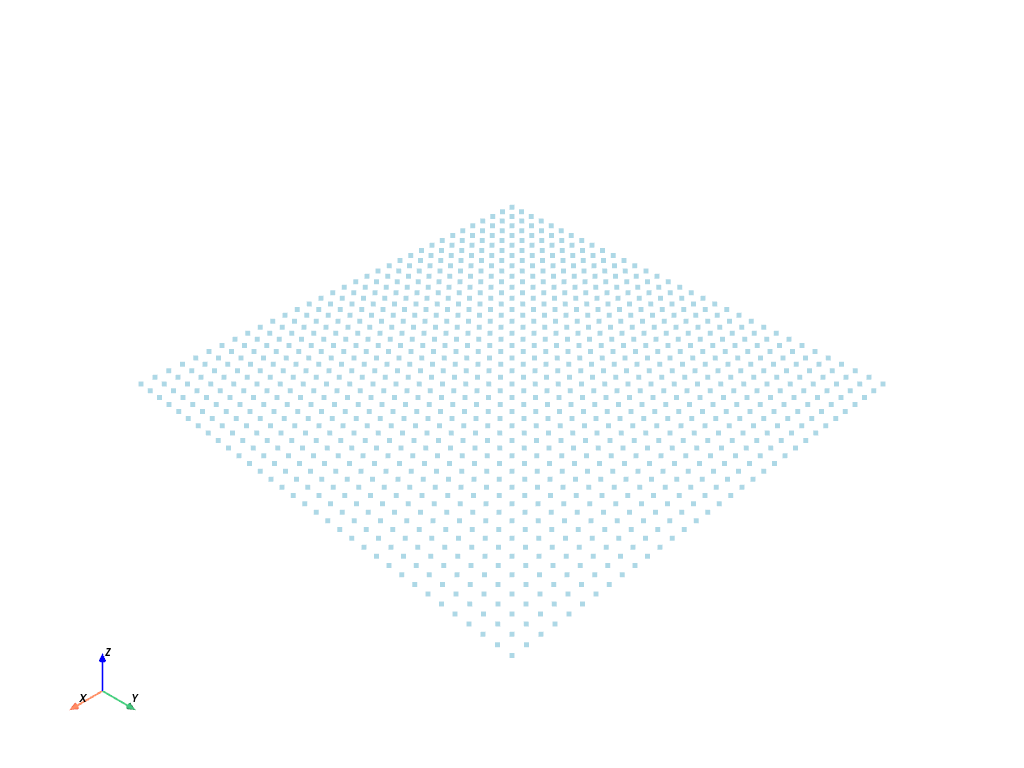

In [ ]:
import pyvista as pv
from dolfinx.plot import vtk_mesh

# create a VTK mesh and attach the solution values from u_h as cell data
out = vtk_mesh(u_h.function_space.mesh)
pyvista_mesh = pv.wrap(out[-1])
pyvista_mesh.plot()

In [32]:
u_h = w_h.sub(1).collapse()

MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


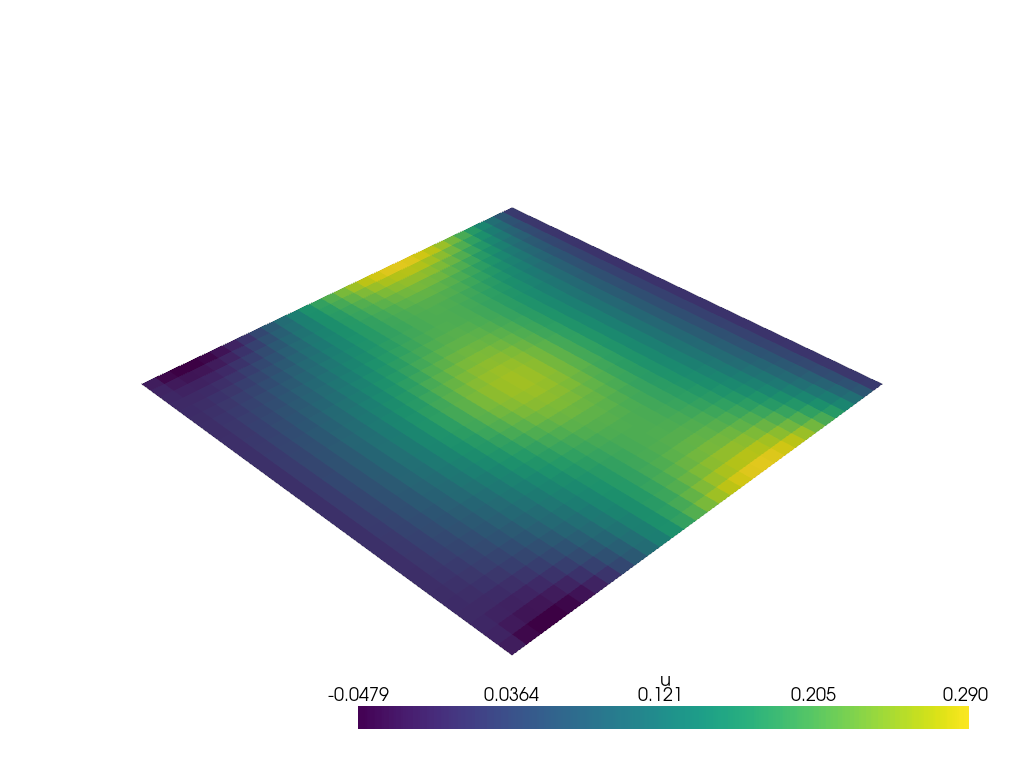

In [68]:
import pyvista
from dolfinx import plot

mesh = u_h.function_space.mesh
cells, types, x = plot.vtk_mesh(mesh, mesh.topology.dim)
grid = pyvista.UnstructuredGrid(cells, types, x)

# If 2D vector field, reshape to (N, 2)
grid["u"] = u_h.x.array
# grid["u_y"] = vals[:, 1]
# grid["u_mag"] = np.sqrt(vals[:, 0]**2 + vals[:, 1]**2)

plotter = pyvista.Plotter()
plotter.add_mesh(grid, scalars="u", cmap="viridis")
plotter.show()

In [ ]:
import numpy as np
import dolfinx
from dolfinx import mesh, fem, io
from mpi4py import MPI
import ufl
import pyvista

# Make sure PyVista is set to work inside Jupyter

# 1. Create or import a 2D mesh
# -------------------------------------------------------
# For a simple rectangle, we can directly create a rectangular mesh. For the cylinder,
# we can either embed it in the mesh with gmsh or approximate a circle with a refined region.
# As a simplistic approach here, we'll just do a rectangle. To truly have a cylinder, 
# you typically use gmsh or an external tool. We'll illustrate a rectangle for demonstration.

L = 2.2
H = 0.41
nx, ny = 50, 10  # mesh resolution

domain_mesh = mesh.create_rectangle(
    MPI.COMM_WORLD,
    [np.array([0.0, 0.0]), np.array([L, H])],
    [nx, ny],
    cell_type=mesh.CellType.triangle
)

# 2. Define function spaces for velocity (vector) and pressure (scalar)
# -------------------------------------------------------
V = fem.functionspace(domain_mesh, ("CG", 2))  # velocity space (quadratic)
Q = fem.functionspace(domain_mesh, ("CG", 1))  # pressure space (linear)

# 3. Mark boundaries and define boundary conditions
# -------------------------------------------------------
# Let's define boundary markers for:
#  - Inflow (x=0)
#  - Outflow (x=L)
#  - Walls (y=0 or y=H)
#  We'll assume no-slip on the walls for velocity,
#  inflow has a parabolic velocity profile,
#  outflow uses a "do-nothing" or zero normal gradient for velocity (implicitly).

# A helper function to identify boundaries:
def boundary_inflow(x):
    return np.isclose(x[0], 0.0)

def boundary_outflow(x):
    return np.isclose(x[0], L)

def boundary_walls(x):
    return np.isclose(x[1], 0.0) | np.isclose(x[1], H)

# Let's define a parabolic inflow profile u(y) = 4*U_max*y*(H - y)/H^2
U_max = 1.0

def inflow_velocity_expression(x):
    # Parabolic in the vertical (y) direction
    return np.stack((4 * U_max * x[1] * (H - x[1]) / H**2, 
                     np.zeros_like(x[1]))).T

# Now let's turn that into a Dirichlet BC
#  We will create a fem.Function that we can use for boundary conditions.
inflow_velocity = fem.Function(V)
inflow_velocity.x.array[:] = 0.0

# Interpolate the expression
inflow_velocity.interpolate(inflow_velocity_expression)

# For the no-slip boundary condition, the velocity is (0,0).
noslip_velocity = np.array([0.0, 0.0], dtype=np.float64)

# Create Dirichlet boundary conditions
bc_inflow = fem.dirichletbc(inflow_velocity, fem.locate_dofs_geometrical(V, boundary_inflow))
bc_walls = fem.dirichletbc(noslip_velocity, fem.locate_dofs_geometrical(V, boundary_walls), V)
# We won't explicitly set Dirichlet for the outflow in velocity, so that
# do-nothing condition is used for the outflow (typical for Navier–Stokes).

bcs = [bc_inflow, bc_walls]

# 4. Define Navier–Stokes problem (steady-state)
# -------------------------------------------------------
# We solve:
#   rho*(u · grad(u)) - div(sigma(u,p)) = 0
#   div(u) = 0
# where sigma(u,p) = 2*mu*eps(u) - pI and eps(u) is the strain rate.
# For simplicity, let's set density=1, viscosity=0.001

mu = 1.0e-3
u = fem.Function(V)
v = ufl.TestFunction(V)
p = fem.Function(Q)
q = ufl.TestFunction(Q)

u_trial = ufl.TrialFunction(V)
p_trial = ufl.TrialFunction(Q)

u_n = fem.Function(V)  # for iteration

# Nonlinear form for Navier–Stokes
# Strain-rate tensor
def epsilon(u_):
    return 0.5*(ufl.grad(u_) + ufl.grad(u_).T)

F_momentum = (ufl.inner(u_n*ufl.grad(u_n), v)*ufl.dx
              + 2*mu*ufl.inner(epsilon(u_n), epsilon(v))*ufl.dx
              - ufl.div(v)*p*ufl.dx
              )

F_continuity = (ufl.div(u_n)*q*ufl.dx)

F = F_momentum + F_continuity

# We can use a Picard or Newton iteration. For demonstration, let's do Picard iteration.

# 5. Assemble system & solve iteratively
# -------------------------------------------------------
# We'll do multiple iterations: on each iteration, we solve a linear sub-problem for u, p.

solver_tolerance = 1e-6
max_iterations = 20

# Pre-create linear solvers for velocity and pressure
u_solver = fem.LinearProblem(
    ufl.lhs(F_momentum),
    ufl.rhs(F_momentum),
    bcs=bcs,
    petsc_options={"ksp_type": "gmres", "pc_type": "ilu"}
)

p_solver = fem.LinearProblem(
    ufl.lhs(F_continuity),
    ufl.rhs(F_continuity),
    bcs=[],  # Pressure typically no Dirichlet BC in standard formulation
    petsc_options={"ksp_type": "gmres", "pc_type": "ilu"}
)

for i in range(max_iterations):
    # Solve for velocity with the current pressure guess
    u_solver.A = fem.assemble_matrix(ufl.lhs(F_momentum), bcs=bcs)
    u_solver.b = fem.assemble_vector(ufl.rhs(F_momentum))
    fem.apply_lifting(u_solver.b, [u_solver.A], [bcs])
    u_solver.b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    u_solver.solve(u)
    
    # Solve for pressure with updated velocity
    p_solver.A = fem.assemble_matrix(ufl.lhs(F_continuity))
    p_solver.b = fem.assemble_vector(ufl.rhs(F_continuity))
    p_solver.solve(p)

    # Compute update error
    u_diff = fem.Function(V)
    u_diff.vector.array[:] = u.vector.array - u_n.vector.array
    error_u = np.linalg.norm(u_diff.vector.array, ord=np.inf)

    # Copy the new solution into u_n for the next iteration
    u_n.x.array[:] = u.x.array
    
    if MPI.COMM_WORLD.rank == 0:
        print(f"Iteration {i}, velocity update norm = {error_u:.6e}")

    if error_u < solver_tolerance:
        if MPI.COMM_WORLD.rank == 0:
            print("Converged!")
        break

# 6. Visualize results inside the notebook
# -------------------------------------------------------
# We can use PyVista to visualize the solution fields.

# Convert solution functions to a PyVista mesh
topology, cell_types, geometry = dolfinx.plot.create_vtk_mesh(domain_mesh, domain_mesh.topology.dim)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

# Get velocity array
u_vals = np.zeros((domain_mesh.topology.index_map(domain_mesh.topology.dim).size_local, 2))
u_vals[:] = u.x.array.reshape((-1, 2))  # shape: (num_vertices, 2)
grid["u_x"] = u_vals[:, 0]
grid["u_y"] = u_vals[:, 1]

# Get pressure array
p_vals = p.x.array
grid["p"] = p_vals

# Plot velocity magnitude
plotter = pyvista.PlotterITK()
plotter.add_mesh(grid.copy(), scalars=np.sqrt(u_vals[:,0]**2 + u_vals[:,1]**2), 
                 cmap="viridis", show_edges=False)
plotter.add_title("Velocity Magnitude")
plotter.show()

# Similarly, we can plot pressure
plotter_p = pyvista.PlotterITK()
plotter_p.add_mesh(grid.copy(), scalars=p_vals, cmap="plasma", show_edges=False)
plotter_p.add_title("Pressure")
plotter_p.show()

# 7. (Optional) Save solutions for offline processing
# -------------------------------------------------------
with io.XDMFFile(MPI.COMM_WORLD, "navier_stokes_solution.xdmf", "w") as xdmf:
    xdmf.write_mesh(domain_mesh)
    xdmf.write_function(u, "velocity")
    xdmf.write_function(p, "pressure")
